Step 1: Import Required Libraries

In [2]:
import pandas as pd  # loading data
import numpy as np   # for mathematical calculation
import re  # regular expressions cleaning the data
import nltk  # for basics
import matplotlib.pyplot as plt  # visualization
from nltk.corpus import stopwords  # to remove be verds unwanted words
from nltk.tokenize import word_tokenize  # split the words
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Step 2: create sample customer review

In [3]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

#Display first few rows
print("Customer Reviews Dataset")
print(df.head())

Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


Step 3: Text Cleaning and Preprocessing


In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

  # Convert to lowercase
  text = text.lower()
  print('lower case', text)

  #Remove special characters and numbers
  text = re.sub('[^a-zA-Z]', ' ', text)
  print(' remove special characters and numbers', text)

  #Tokenization
  words = word_tokenize(text)
  print('tokenization', words)

  #Remove stopwords
  words = [word for word in words if word not in stop_words]
  print('stopwords', words)

  # Join words again
  cleaned_text = ' '.join(words)
  print('join words again', cleaned_text)

  return cleaned_text

# Apply cleaning function
df['Cleaned_Review'] = df['Review'].apply(clean_text)

# Display cleaned reviews
print("\nCleaned Reviews:")
print(df['Cleaned_Review'])

lower case the product quality is excellent and delivery was very fast.
 remove special characters and numbers the product quality is excellent and delivery was very fast 
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
join words again product quality excellent delivery fast
lower case very bad packaging and the item was damaged.
 remove special characters and numbers very bad packaging and the item was damaged 
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
join words again bad packaging item damaged
lower case customer service was helpful and responsive.
 remove special characters and numbers customer service was helpful and responsive 
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
join words

In [6]:
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):
  score = sia.polarity_scores(review)

  compound = score['compound']

  if compound >= 0.05:
    return 'Positive'
  elif compound <= -0.05:
    return 'Negative'
  else:
    return 'Neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

print("\nSentiment Analysis Results:")
print(df[['Review', 'Sentiment']])


Sentiment Analysis Results:
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


Step 5: Find Common Keywords

In [7]:
all_words = " ".join(df['Cleaned_Review'])

word_list = all_words.split()

#Count word frequency
word_freq = Counter(word_list)

# Display top 10 keywords
print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))



Top 10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


Step 6: Identify Common Complaints

In [8]:
negative_words = df[df['Sentiment'] == 'Negative']

negative_words = " ".join(negative_words['Cleaned_Review'])

negative_word_list = negative_words.split()

negative_word_freq = Counter(negative_word_list)

print("\nTop 10 Common Negative Keywords")
print(negative_word_freq.most_common(10))


Top 10 Common Negative Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


Step 7: Visualization - Sentiment Count

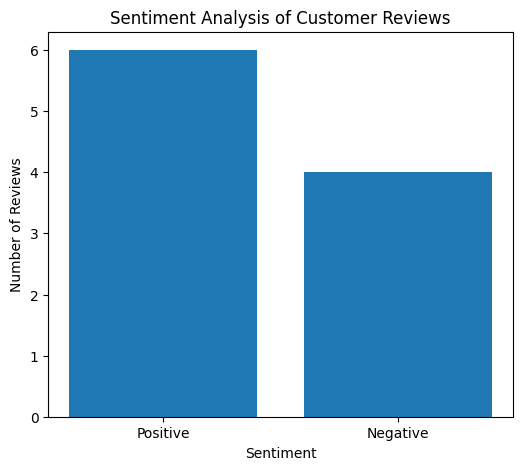

In [9]:
sentiment_counts = df['Sentiment'].value_counts() # it will give category count

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Sentiment Analysis of Customer Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

Step 8: Genrate Word CLoud

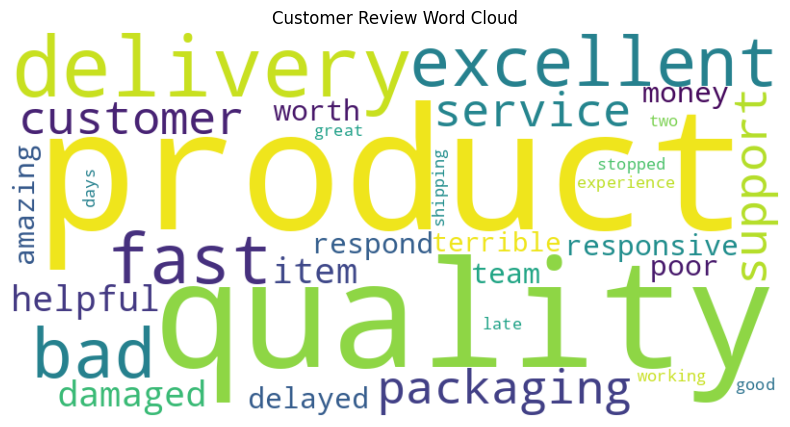

In [10]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.title("Customer Review Word Cloud")
plt.show()